<a href="https://colab.research.google.com/github/Samara856/Stroke_risk_dataset_ML/blob/main/ML_Lab_Final(Stroke_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTS

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, BaggingClassifier,
                               StackingClassifier, VotingClassifier, ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

In [42]:
df = pd.read_csv("/content/stroke_risk_dataset.csv")

df.columns

df['At Risk (Binary)'].value_counts()

,count
At Risk (Binary),
1,45444
0,24556


EXPLORATORY DATA ANALYSIS


EXPLORATORY DATA ANALYSIS
                                  count       mean        std   min   25%  \
Chest Pain                      70000.0   0.501871   0.500000   0.0   0.0   
Shortness of Breath             70000.0   0.496471   0.499991   0.0   0.0   
Irregular Heartbeat             70000.0   0.498886   0.500002   0.0   0.0   
Fatigue & Weakness              70000.0   0.500100   0.500004   0.0   0.0   
Dizziness                       70000.0   0.503043   0.499994   0.0   0.0   
Swelling (Edema)                70000.0   0.500557   0.500003   0.0   0.0   
Pain in Neck/Jaw/Shoulder/Back  70000.0   0.499186   0.500003   0.0   0.0   
Excessive Sweating              70000.0   0.503671   0.499990   0.0   0.0   
Persistent Cough                70000.0   0.500800   0.500003   0.0   0.0   
Nausea/Vomiting                 70000.0   0.501943   0.500000   0.0   0.0   
High Blood Pressure             70000.0   0.500643   0.500003   0.0   0.0   
Chest Discomfort (Activity)     70000.0   0.49955

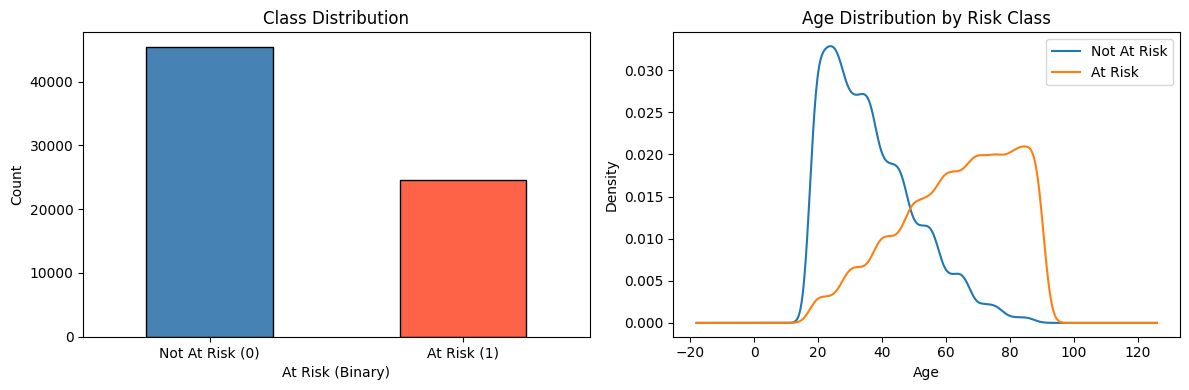

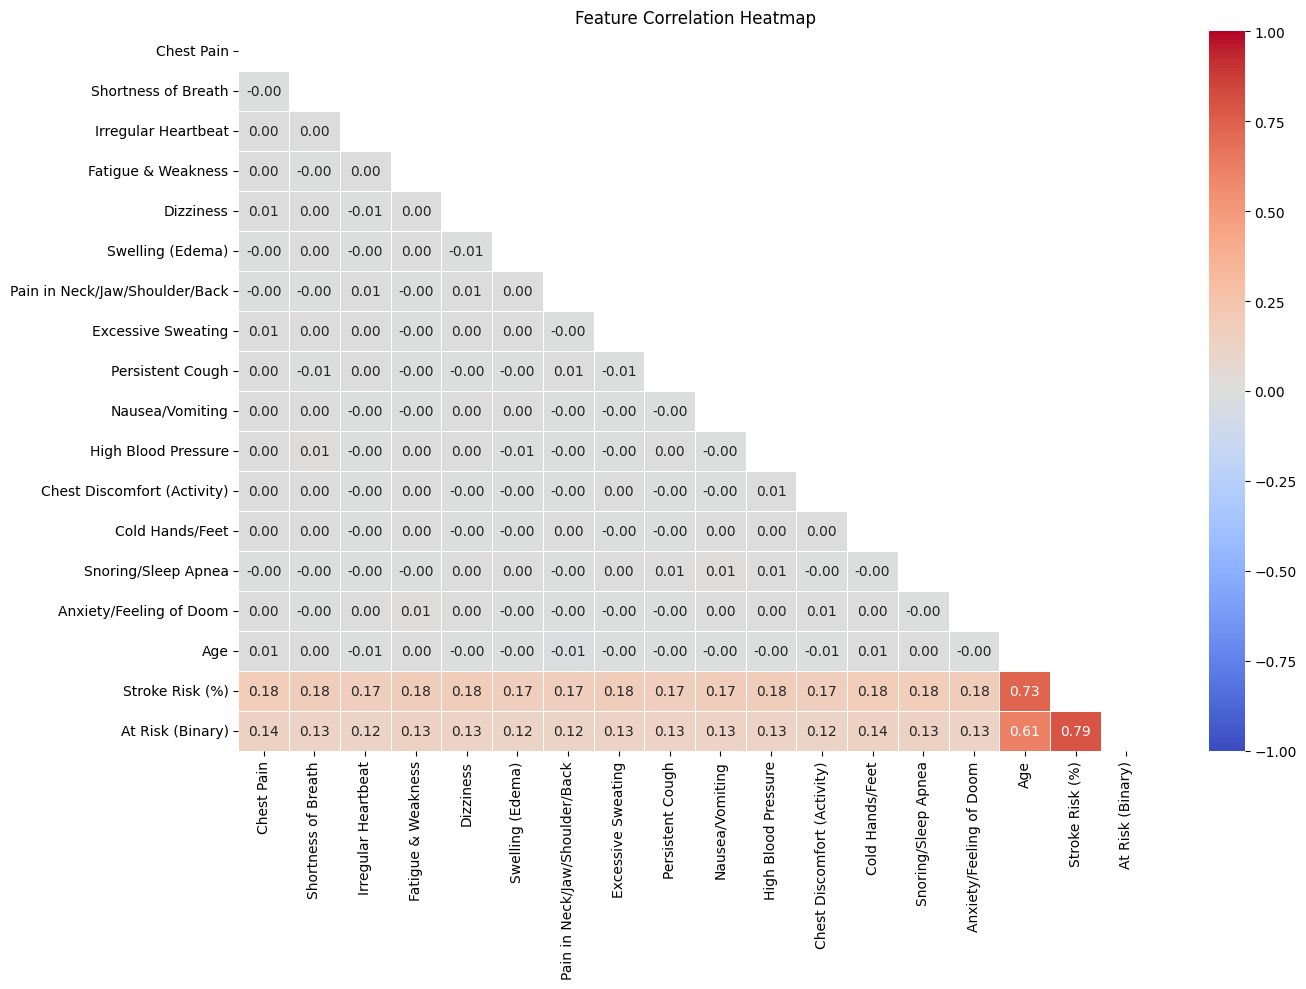

In [43]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)
print(df.describe().T)

# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['At Risk (Binary)'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not At Risk (0)', 'At Risk (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Age distribution by class
df.groupby('At Risk (Binary)')['Age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Risk Class')
axes[1].set_xlabel('Age')
axes[1].legend(['Not At Risk', 'At Risk'])

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


FEATURE ENGINEERING & SPLIT

In [44]:
TARGET = 'At Risk (Binary)'

DROP = ['Stroke Risk (%)']

# Check correlations to identify any potential leaks
correlation_matrix = df.corr()
target_correlations = correlation_matrix[TARGET].sort_values(ascending=False)
print("\nCorrelations with target:")
print(target_correlations)

# Identify features with suspiciously high correlation (>0.95)
high_corr_features = target_correlations[abs(target_correlations) > 0.95].index.tolist()
if TARGET in high_corr_features:
    high_corr_features.remove(TARGET)
if high_corr_features:
    print(f"\n⚠️ WARNING: Features with suspiciously high correlation ({high_corr_features})")
    DROP.extend(high_corr_features)

X = df.drop(columns=[TARGET] + DROP)
y = df[TARGET]

print(f"\nFeatures used : {list(X.columns)}")
print(f"Target        : {TARGET}")

# Train / Test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTrain size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

# Feature scaling (needed for LR, KNN, SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Shared results list and trained models dict
results        = []
trained_models = {}


Correlations with target:
At Risk (Binary)                  1.000000
Stroke Risk (%)                   0.790743
Age                               0.612038
Cold Hands/Feet                   0.136642
Chest Pain                        0.135365
Snoring/Sleep Apnea               0.133681
Fatigue & Weakness                0.133060
Excessive Sweating                0.132806
High Blood Pressure               0.132301
Anxiety/Feeling of Doom           0.131466
Shortness of Breath               0.130482
Dizziness                         0.130444
Persistent Cough                  0.128700
Nausea/Vomiting                   0.128645
Irregular Heartbeat               0.124150
Chest Discomfort (Activity)       0.123640
Swelling (Edema)                  0.122416
Pain in Neck/Jaw/Shoulder/Back    0.120280
Name: At Risk (Binary), dtype: float64

Features used : ['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/

MODEL 1 - LOGISTIC REGRESSION

In [45]:
print("\n" + "=" * 60)
print("MODEL 1: Logistic Regression (L2, C=0.0001)")
print("=" * 60)

results = [r for r in results if r['Model'] != "Logistic Regression (L2, C=0.0001)"]


name  = "Logistic Regression (L2, C=0.0001)"
model = LogisticRegression(C=0.0001, max_iter=1000, random_state=42)

model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, True, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 1: Logistic Regression (L2, C=0.0001)
  Acc=0.8983  F1=0.9274  AUC=0.9991
              precision    recall  f1-score   support

 Not At Risk       1.00      0.71      0.83      4911
     At Risk       0.86      1.00      0.93      9089

    accuracy                           0.90     14000
   macro avg       0.93      0.86      0.88     14000
weighted avg       0.91      0.90      0.89     14000



MODEL 2 — DECISION TREE

In [46]:
print("\n" + "=" * 60)
print("MODEL 2: Decision Tree")
print("=" * 60)

name  = "Decision Tree"
model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, False, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 2: Decision Tree
  Acc=0.8224  F1=0.8646  AUC=0.8956
              precision    recall  f1-score   support

 Not At Risk       0.76      0.73      0.74      4911
     At Risk       0.86      0.87      0.86      9089

    accuracy                           0.82     14000
   macro avg       0.81      0.80      0.80     14000
weighted avg       0.82      0.82      0.82     14000



MODEL 3 — RANDOM FOREST

In [47]:
print("\n" + "=" * 60)
print("MODEL 3: Random Forest")
print("=" * 60)

name  = "Random Forest"
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, False, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 3: Random Forest
  Acc=0.923  F1=0.9413  AUC=0.9816
              precision    recall  f1-score   support

 Not At Risk       0.91      0.87      0.89      4911
     At Risk       0.93      0.95      0.94      9089

    accuracy                           0.92     14000
   macro avg       0.92      0.91      0.91     14000
weighted avg       0.92      0.92      0.92     14000



MODEL 4 — EXTRA TREES

In [48]:
print("\n" + "=" * 60)
print("MODEL 4: Extra Trees")
print("=" * 60)

name  = "Extra Trees"
model = ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, False, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 4: Extra Trees
  Acc=0.9271  F1=0.9457  AUC=0.9852
              precision    recall  f1-score   support

 Not At Risk       0.95      0.83      0.89      4911
     At Risk       0.92      0.98      0.95      9089

    accuracy                           0.93     14000
   macro avg       0.93      0.91      0.92     14000
weighted avg       0.93      0.93      0.93     14000



 MODEL 5 — KNN

In [49]:
print("\n" + "=" * 60)
print("MODEL 5: KNN")
print("=" * 60)

name  = "KNN"
model = KNeighborsClassifier(n_neighbors=10)

model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, True, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))





MODEL 5: KNN
  Acc=0.9175  F1=0.9365  AUC=0.9737
              precision    recall  f1-score   support

 Not At Risk       0.88      0.88      0.88      4911
     At Risk       0.94      0.94      0.94      9089

    accuracy                           0.92     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.92      0.92      0.92     14000



MODEL 6 — SVM

In [50]:
print("\n" + "=" * 60)
print("MODEL 6: SVM")
print("=" * 60)

name  = "SVM"
model = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)

model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, True, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 6: SVM
  Acc=0.9922  F1=0.994  AUC=0.9998
              precision    recall  f1-score   support

 Not At Risk       0.99      0.99      0.99      4911
     At Risk       0.99      1.00      0.99      9089

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



MODEL 7 — NAIVE BAYES

In [51]:
print("\n" + "=" * 60)
print("MODEL 7: Naive Bayes")
print("=" * 60)

name  = "Naive Bayes"
model = GaussianNB()

model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, True, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 7: Naive Bayes
  Acc=0.9296  F1=0.9464  AUC=0.9779
              precision    recall  f1-score   support

 Not At Risk       0.92      0.88      0.90      4911
     At Risk       0.94      0.96      0.95      9089

    accuracy                           0.93     14000
   macro avg       0.93      0.92      0.92     14000
weighted avg       0.93      0.93      0.93     14000



MODEL 8 — GRADIENT BOOSTING

In [52]:
print("\n" + "=" * 60)
print("MODEL 8: Gradient Boosting")
print("=" * 60)

name  = "Gradient Boosting"
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, False, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 8: Gradient Boosting
  Acc=0.9609  F1=0.9703  AUC=0.9919
              precision    recall  f1-score   support

 Not At Risk       0.97      0.92      0.94      4911
     At Risk       0.96      0.98      0.97      9089

    accuracy                           0.96     14000
   macro avg       0.96      0.95      0.96     14000
weighted avg       0.96      0.96      0.96     14000



 MODEL 9 — XGBOOST

In [53]:
print("\n" + "=" * 60)
print("MODEL 9: XGBoost")
print("=" * 60)

name  = "XGBoost"
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
    max_depth=3,
    learning_rate=0.1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, False, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 9: XGBoost
  Acc=0.9585  F1=0.9684  AUC=0.9938
              precision    recall  f1-score   support

 Not At Risk       0.96      0.92      0.94      4911
     At Risk       0.96      0.98      0.97      9089

    accuracy                           0.96     14000
   macro avg       0.96      0.95      0.95     14000
weighted avg       0.96      0.96      0.96     14000



MODEL 10 — LIGHTGBM

In [54]:
print("\n" + "=" * 60)
print("MODEL 10: LightGBM")
print("=" * 60)

name  = "LightGBM"
model = LGBMClassifier(random_state=42, verbose=-1, max_depth=3, learning_rate=0.1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'Model'    : name,
    'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred), 4),
    'Recall'   : round(recall_score(y_test, y_pred),    4),
    'F1 Score' : round(f1_score(y_test, y_pred),        4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4),
}

results.append(metrics)
trained_models[name] = (model, False, y_pred)

print(f"  Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))



MODEL 10: LightGBM
  Acc=0.958  F1=0.968  AUC=0.9937
              precision    recall  f1-score   support

 Not At Risk       0.96      0.92      0.94      4911
     At Risk       0.96      0.98      0.97      9089

    accuracy                           0.96     14000
   macro avg       0.96      0.95      0.95     14000
weighted avg       0.96      0.96      0.96     14000



COMPARISON TABLE

In [55]:
print("\n" + "=" * 60)
print("📊 ALL MODELS — COMPARISON TABLE")
print("=" * 60)

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

# Highlight best model per metric
print("\n🏆 Best model per metric:")
for col in results_df.columns:
    best = results_df[col].astype(float).idxmax()
    print(f"  {col:12s} → {best}  ({results_df.loc[best, col]})")


📊 ALL MODELS — COMPARISON TABLE
                                    Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                                             
Logistic Regression (L2, C=0.0001)    0.8983     0.8645  1.0000    0.9274   0.9991
Decision Tree                         0.8224     0.8563  0.8730    0.8646   0.8956
Random Forest                         0.9230     0.9318  0.9510    0.9413   0.9816
Extra Trees                           0.9271     0.9156  0.9779    0.9457   0.9852
KNN                                   0.9175     0.9363  0.9366    0.9365   0.9737
SVM                                   0.9922     0.9924  0.9956    0.9940   0.9998
Naive Bayes                           0.9296     0.9359  0.9572    0.9464   0.9779
Gradient Boosting                     0.9609     0.9586  0.9823    0.9703   0.9919
XGBoost                               0.9585     0.9588  0.9781    0.9684   0.9938
LightGBM                              0.9580     0.958

VISUALISE BASE MODEL METRICS

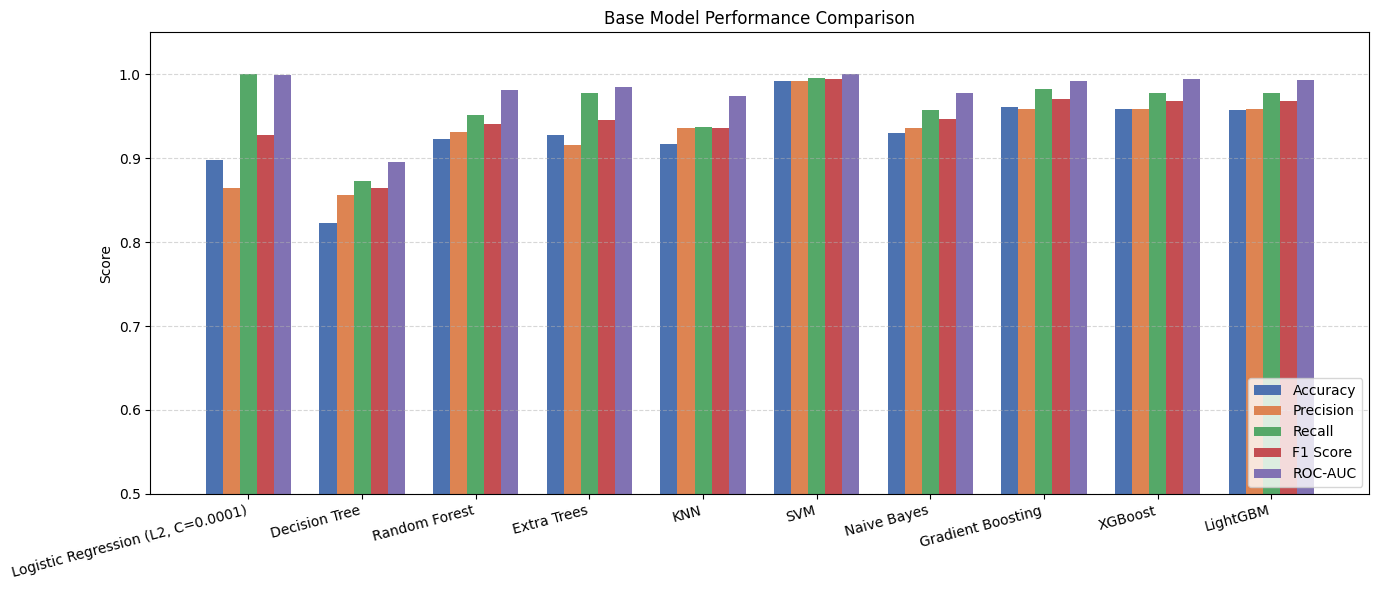

In [56]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_df = results_df[metrics_to_plot].astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
x      = np.arange(len(plot_df))
w      = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * w, plot_df[metric], width=w, label=metric, color=colors[i])

ax.set_xticks(x + w * 2)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Base Model Performance Comparison')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('base_model_comparison.png', dpi=150)
plt.show()

CONFUSION MATRICES

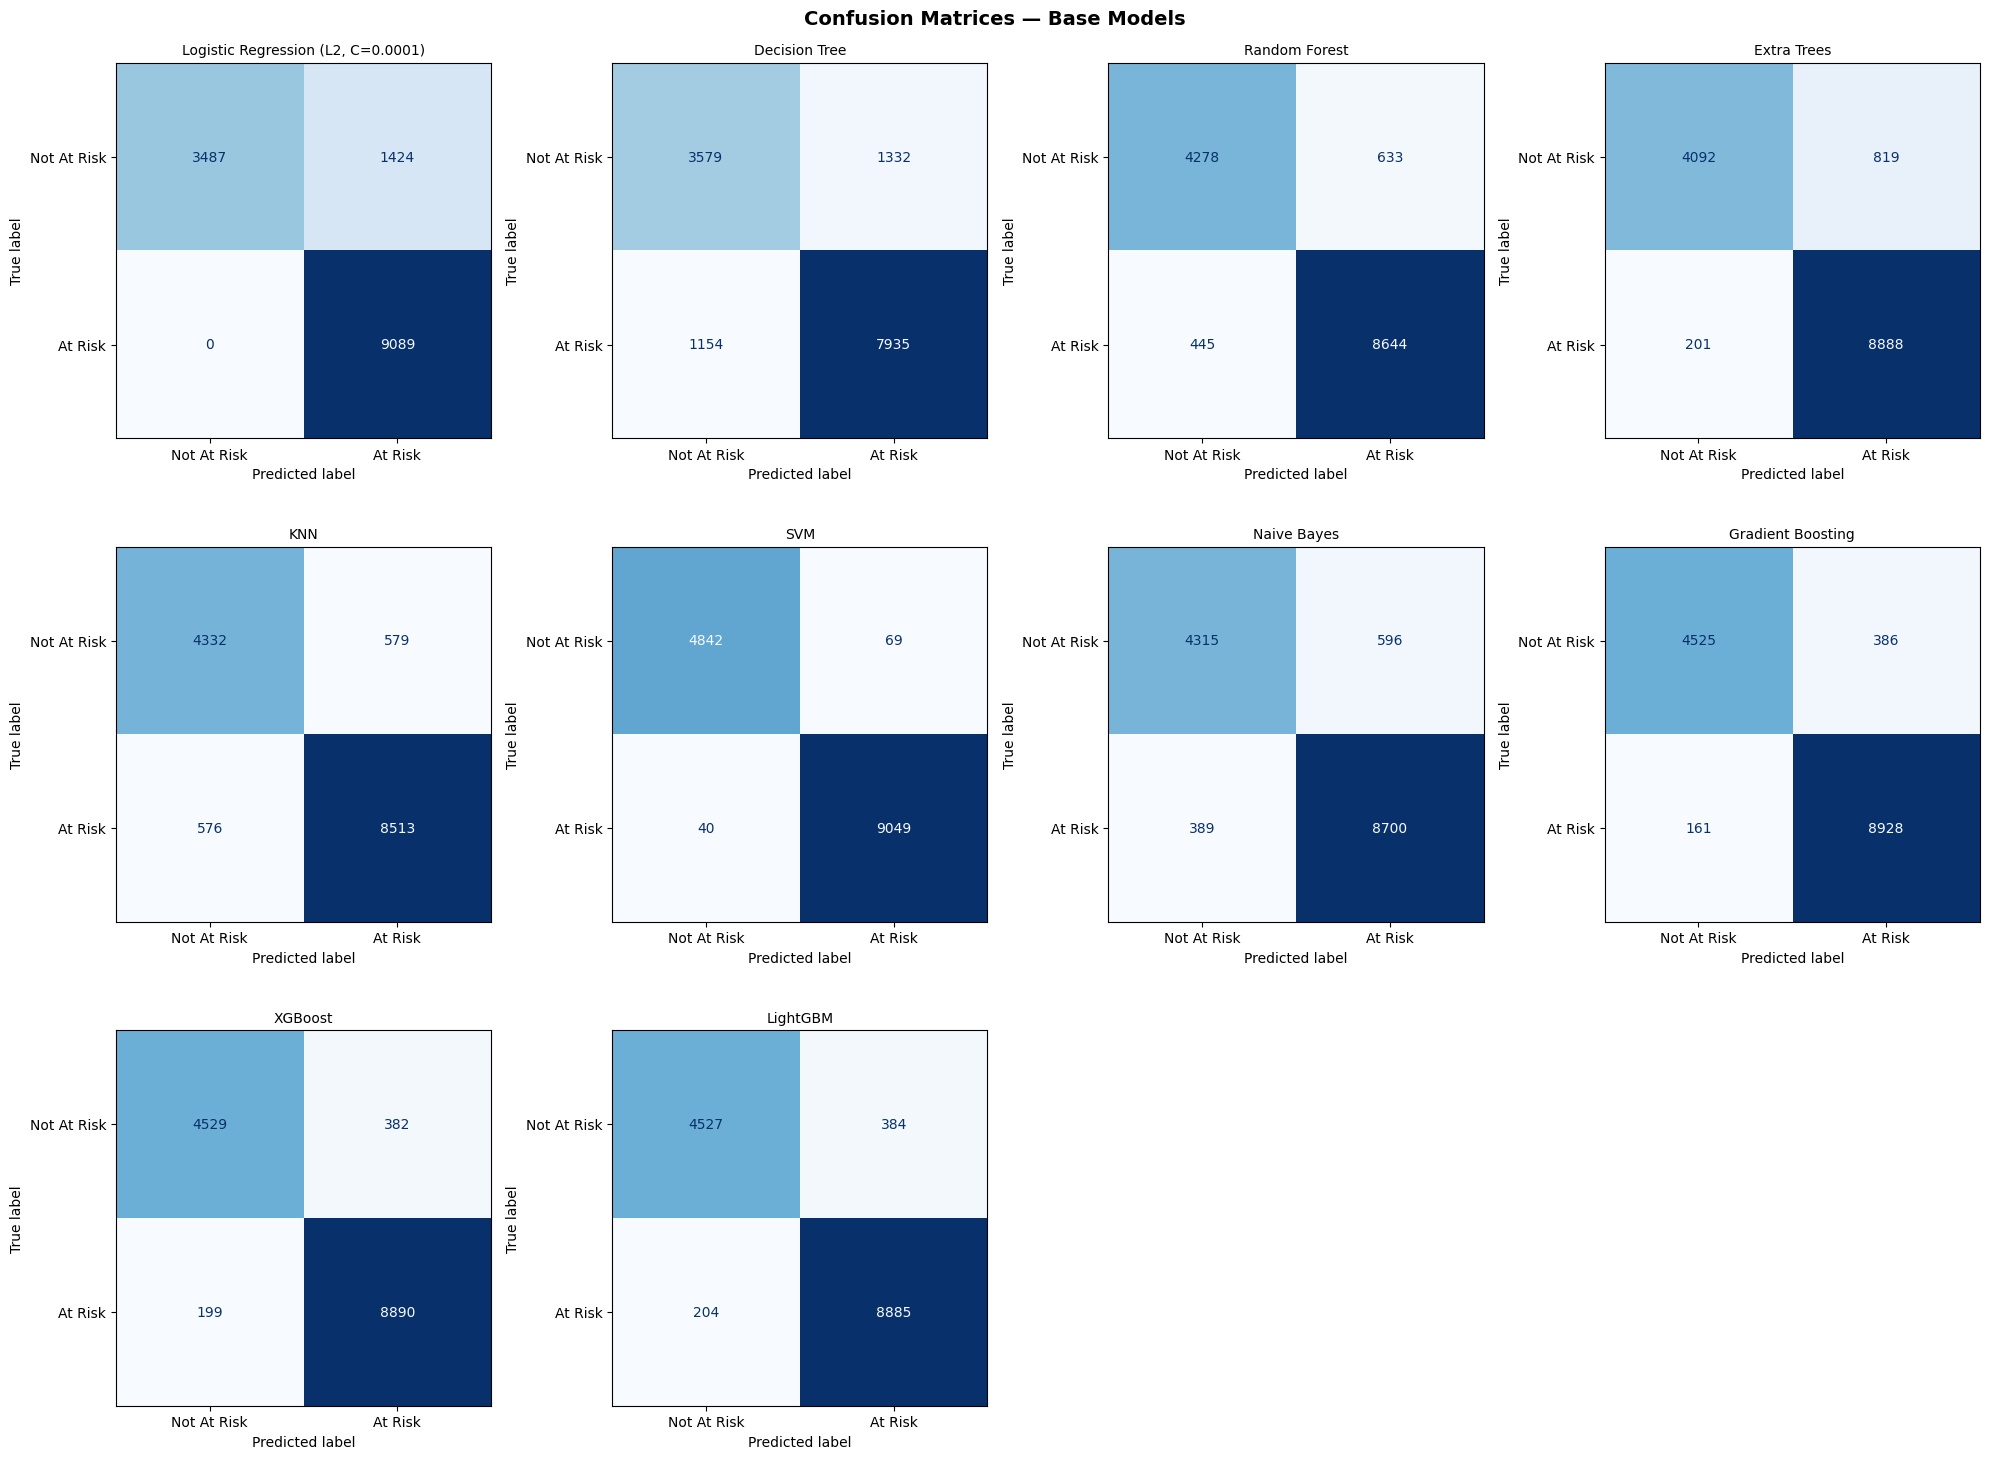

In [57]:
num_models = len(trained_models)
rows = (num_models + 3) // 4

fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for idx, (name, (fitted, scaled, y_pred)) in enumerate(trained_models.items()):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not At Risk', 'At Risk'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=10)

for i in range(num_models, len(axes)):
    axes[i].axis('off')

plt.suptitle('Confusion Matrices — Base Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_base.png', dpi=150)
plt.show()


ROC CURVES

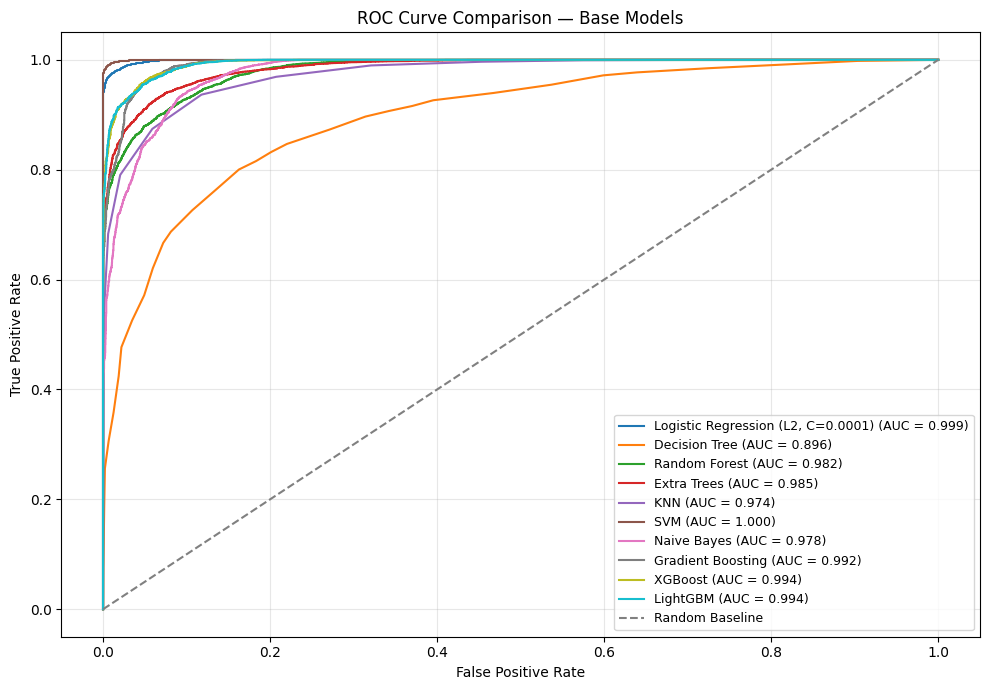

In [58]:
plt.figure(figsize=(10, 7))

for name, (fitted, scaled, y_pred) in trained_models.items():

    X_used = X_test_sc if scaled else X_test

    if hasattr(fitted, "predict_proba"):
        y_score = fitted.predict_proba(X_used)[:, 1]
    else:
        y_score = fitted.decision_function(X_used)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc     = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Base Models")
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_comparison.png", dpi=150)
plt.show()